**Daily Challenge : Advanced Data Analysis and Problem Solving with SciPy and NumPy**

In [5]:
import numpy as np
import pandas as pd

# Seed for reproducibility
np.random.seed(0)

# Number of entries
n_entries = 1000

# Simulating dataset
time = np.linspace(0, 100, n_entries)  # Time variable
temperature = 20 + 5 * np.sin(np.pi * time / 50) + np.random.normal(0, 0.5, n_entries)  # Temperature (with some noise)
pressure = 1013 + 20 * np.cos(np.pi * time / 25) + np.random.normal(0, 1, n_entries)  # Pressure (with some noise)
chemical_concentration = 5 + 2 * np.sin(np.pi * time / 10) + np.random.normal(0, 0.2, n_entries)  # Chemical concentration

# Creating DataFrame
ninja_data = pd.DataFrame({
    'Time': time,
    'Temperature': temperature,
    'Pressure': pressure,
    'Chemical Concentration': chemical_concentration
})
ninja_data.head()


,Time,Temperature,Pressure,Chemical Concentration
0,0.0000,20.882026,1033.555963,4.693416
1,0.1001,20.231526,1033.890892,4.720490
2,0.2002,20.552262,1032.571356,5.134934
3,0.3003,21.214783,1033.090475,4.996730
4,0.4004,21.059555,1033.202742,5.234754


In [6]:
# Descriptive Statistics
stats_description = ninja_data.describe()

# Correlation Matrix
correlation_matrix = ninja_data.corr()

# Display the results
print("Descriptive Statistics:")
print(stats_description)

print("\nCorrelation Matrix:")
print(correlation_matrix)



Descriptive Statistics:
              Time  Temperature     Pressure  Chemical Concentration
count  1000.000000  1000.000000  1000.000000             1000.000000
mean     50.000000    19.977372  1013.033617                4.989754
std      28.910854     3.574943    14.203350                1.436505
min       0.000000    13.897407   990.284418                2.559310
25%      25.000000    16.386984   998.852247                3.576024
50%      50.000000    20.008666  1012.950967                4.970976
75%      75.000000    23.570373  1027.062114                6.398067
max     100.000000    26.030294  1035.471676                7.486763

Correlation Matrix:
                            Time  Temperature  Pressure  \
Time                    1.000000    -0.770696 -0.001946   
Temperature            -0.770696     1.000000  0.007112   
Pressure               -0.001946     0.007112  1.000000   
Chemical Concentration -0.156113    -0.003277 -0.000863   

                        Chemical Conce

In [7]:
from scipy.stats import describe
import pandas as pd

# Applying scipy.stats.describe to each numeric column
stats_scipy = {
    column: describe(ninja_data[column])
    for column in ninja_data.select_dtypes(include=[np.number]).columns
}

# Organizing the results into a DataFrame for better readability
stats_summary = pd.DataFrame({
    "Variable": stats_scipy.keys(),
    "Count": [stat.nobs for stat in stats_scipy.values()],
    "Min": [stat.minmax[0] for stat in stats_scipy.values()],
    "Max": [stat.minmax[1] for stat in stats_scipy.values()],
    "Mean": [stat.mean for stat in stats_scipy.values()],
    "Variance": [stat.variance for stat in stats_scipy.values()],
    "Skewness": [stat.skewness for stat in stats_scipy.values()],
    "Kurtosis": [stat.kurtosis for stat in stats_scipy.values()]
})

# Display the results
print(stats_summary)


                 Variable  Count         Min          Max         Mean  \
0                    Time   1000    0.000000   100.000000    50.000000   
1             Temperature   1000   13.897407    26.030294    19.977372   
2                Pressure   1000  990.284418  1035.471676  1013.033617   
3  Chemical Concentration   1000    2.559310     7.486763     4.989754   

     Variance      Skewness  Kurtosis  
0  835.837506  3.859838e-16 -1.200002  
1   12.780219 -1.244101e-02 -1.452583  
2  201.735150 -4.483531e-03 -1.486007  
3    2.063546 -1.191783e-03 -1.450882  


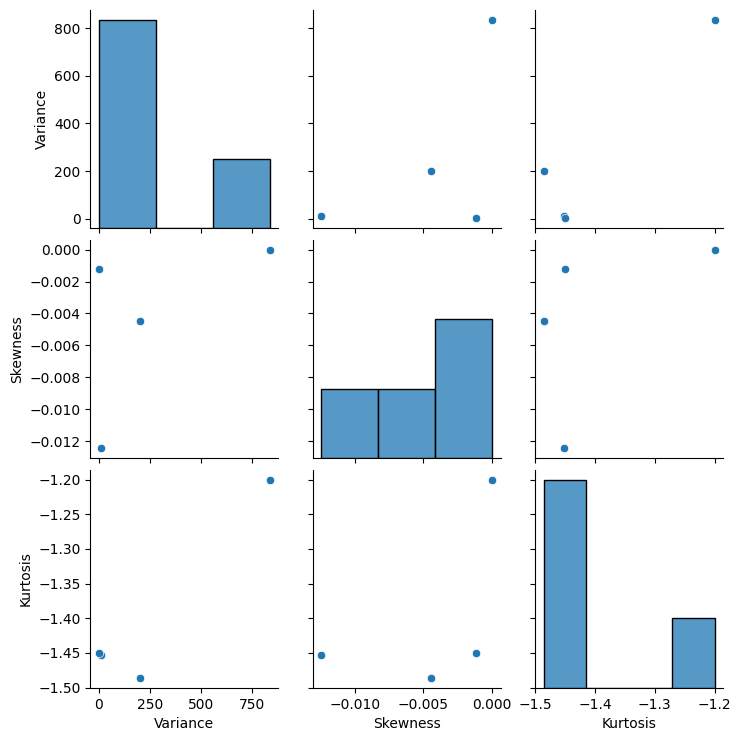

In [35]:

# Filter only numeric data for Variance, Skewness, and Kurtosis
stats_numeric = stats_summary[["Variance", "Skewness", "Kurtosis"]]

# Create pairplot for numeric statistics
sns.pairplot(stats_numeric)
plt.show()


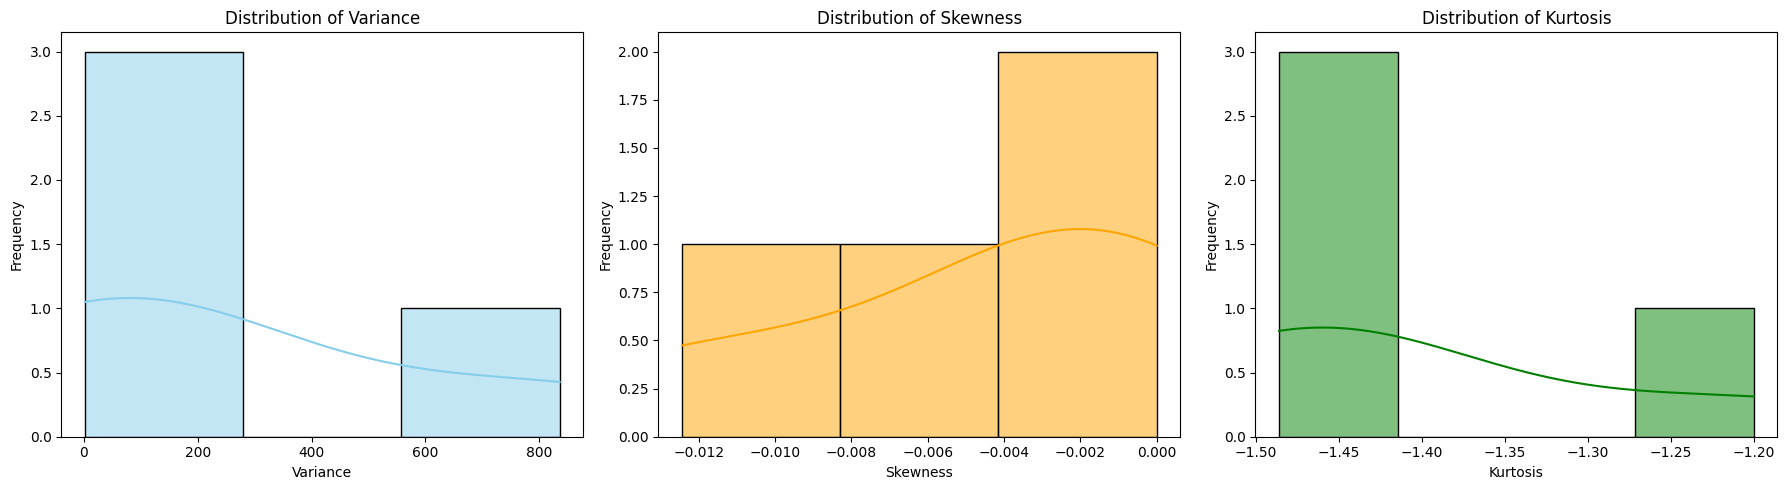

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing individual statistic distributions
plt.figure(figsize=(18, 5))

# Plot Variance
plt.subplot(1, 3, 1)
sns.histplot(stats_summary["Variance"], kde=True, color="skyblue")
plt.title("Distribution of Variance")
plt.xlabel("Variance")
plt.ylabel("Frequency")

# Plot Skewness
plt.subplot(1, 3, 2)
sns.histplot(stats_summary["Skewness"], kde=True, color="orange")
plt.title("Distribution of Skewness")
plt.xlabel("Skewness")
plt.ylabel("Frequency")

# Plot Kurtosis
plt.subplot(1, 3, 3)
sns.histplot(stats_summary["Kurtosis"], kde=True, color="green")
plt.title("Distribution of Kurtosis")
plt.xlabel("Kurtosis")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


**Time:**

Count: 1000 samples.
Range: From 0 to 100 seconds.
Mean: 50 seconds, suggesting the samples are evenly distributed over time.
Variance: High at 835.84, indicating substantial spread in time data.
Skewness: Close to 0, suggesting a symmetric distribution of time values.
Kurtosis: -1.2, indicating a platykurtic distribution (flatter than a normal distribution).

**Temperature: **
Count: 1000 samples.
Range: From 13.9°C to 26.03°C.
Mean: 19.98°C, indicating the central tendency of the temperature data.
Variance: Moderate at 12.78, reflecting some variation in temperature readings.
Skewness: Very close to 0 (-0.012), suggesting an almost symmetric distribution.
Kurtosis: -1.45, showing a flatter-than-normal distribution.

**Pressure:**

Count: 1000 samples.
Range: From 990.28 hPa to 1035.47 hPa.
Mean: 1013.03 hPa, around the typical atmospheric pressure.
Variance: 201.74, a significant spread suggesting noticeable variation in pressure.
Skewness: -0.0045, almost symmetrical.
Kurtosis: -1.49, another platykurtic distribution.
**Chemical Concentration:**
Range: From 2.56 to 7.49 units (likely ppm or a similar measure).
Mean: 4.99 units, the average chemical concentration.
Variance: 2.06, showing smaller variation compared to other variables.
Skewness: Very close to 0 (-0.0012), indicating symmetry.
Kurtosis: -1.45, consistent with a flatter distribution.
Key Observations:
The data for all variables shows symmetry in their distribution (skewness close to 0).
All variables exhibit a platykurtic distribution (kurtosis < 0), indicating less peaked distributions with thinner tails than a normal distribution.
The variance suggests Time and Pressure have larger spreads, while Chemical Concentration shows much lower variability.

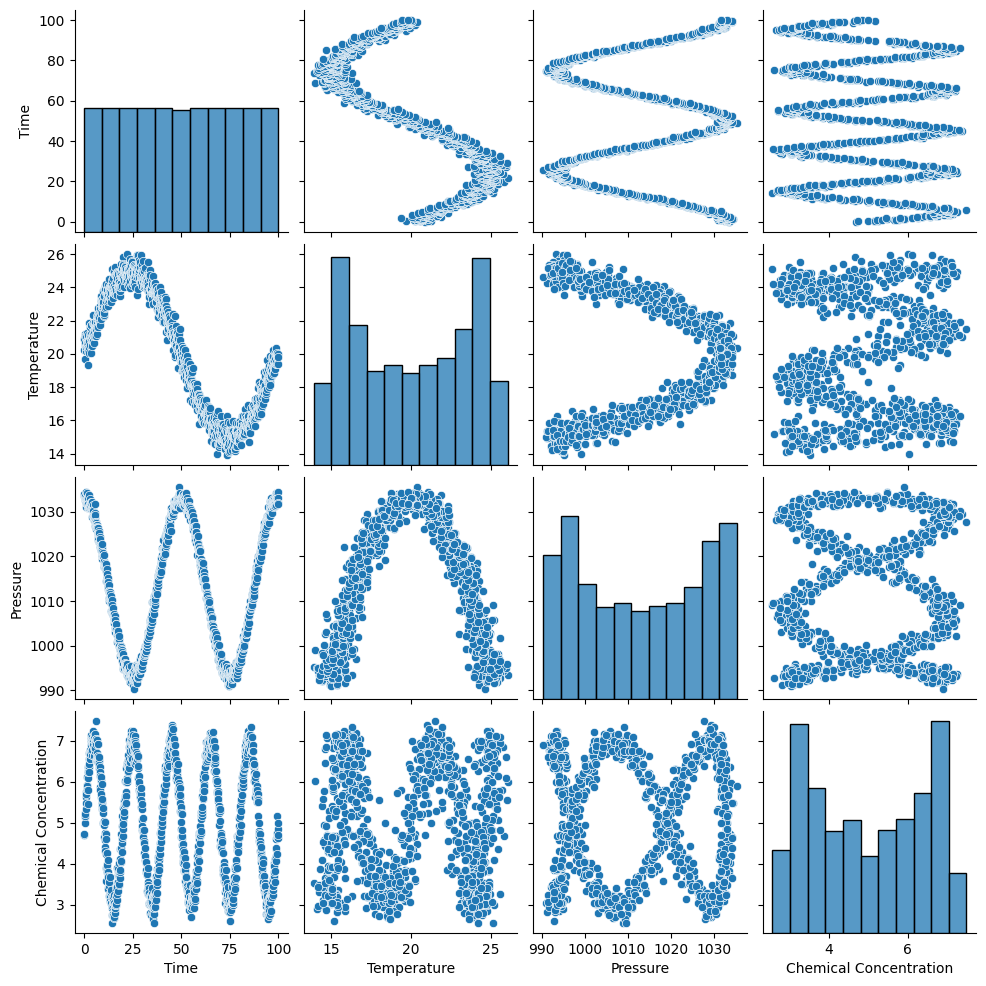

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(ninja_data)
plt.show()

# **Interpretation of Key Patterns:**

**Diagonal Elements (Histograms):**

These show the distribution of each variable:
Time: Uniform distribution across the range (0–100).
Temperature: A roughly bimodal distribution with peaks around 15 and 25°C.
Pressure: Slightly flatter distribution, indicating variations across the 990–1035 hPa range.
Chemical Concentration: Appears multimodal with prominent peaks, reflecting repeating patterns.
Scatterplots:

**Time vs. Other Variables:**

Time vs. Temperature: A sinusoidal relationship is visible, suggesting temperature oscillates periodically with time.
Time vs. Pressure: Also shows a sinusoidal pattern, indicating cyclic changes in pressure with time.
Time vs. Chemical Concentration: Similar sinusoidal pattern, likely reflecting periodic chemical concentration changes over time.
Temperature vs. Pressure:

A clear inverted U-shape relationship is visible, suggesting that temperature and pressure are correlated but not linear. This indicates a bell-shaped interdependence.
Temperature vs. Chemical Concentration:

No clear pattern; scattered distribution indicates weak or no direct relationship.

**Pressure vs. Chemical Concentration:**

The scatterplot reveals a periodic or intertwined relationship, suggesting cyclical interdependence.
Observations:
The sinusoidal relationships between Time and other variables imply that the variables might be influenced by periodic processes (e.g., diurnal or environmental cycles).
Temperature and Pressure show an inverted U-shape dependency, possibly due to atmospheric processes.
The multimodal distributions in Chemical Concentration hint at distinct states or cycles in the data.
These visualizations reinforce the statistics provided earlier, showcasing symmetry and periodicity in the dataset.







**Generating the pairplot with violin and scatterplots**


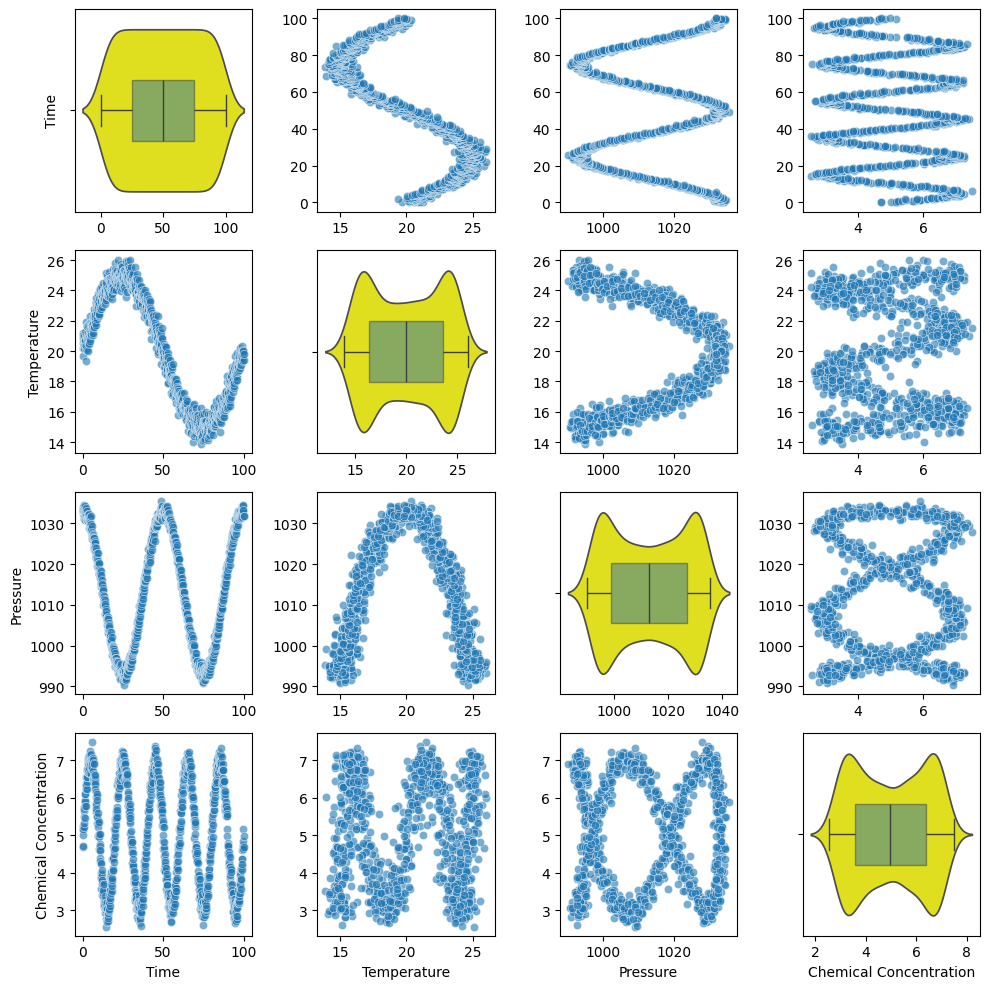

In [11]:

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
variables = ninja_data.columns

for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        ax = axes[i, j]
        if i == j:  # Diagonal plots (violin + boxplot)
            sns.violinplot(data=ninja_data, x=var1, ax=ax, inner=None, color="yellow")
            sns.boxplot(data=ninja_data, x=var1, ax=ax, width=0.3, boxprops=dict(alpha=0.5))
        else:  # Off-diagonal plots (scatterplot)
            sns.scatterplot(data=ninja_data, x=var2, y=var1, ax=ax, alpha=0.6)
        if j == 0:
            ax.set_ylabel(var1)
        else:
            ax.set_ylabel('')
        if i == len(variables) - 1:
            ax.set_xlabel(var2)
        else:
            ax.set_xlabel('')

plt.tight_layout()
plt.show()

**Periodic Behavior**: The scatterplots between Time and the other variables strongly highlight periodicity, consistent with the sinusoidal generation functions.

**Outliers**: Minor outliers are visible in Temperature, Pressure, and Chemical Concentration, mostly at the extreme ranges.

**Non-linear Relationships**: Particularly between Temperature and Pressure, and Pressure and Chemical Concentration.

In [13]:
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler

# Calculating Z-scores for detecting outliers
z_scores = ninja_data.apply(zscore)

# Defining an outlier threshold (e.g., Z-score > 3 or < -3)
outlier_threshold = 3
ninja_data['Outlier'] = (z_scores.abs() > outlier_threshold).any(axis=1)

# Normalizing the data (excluding the 'Outlier' column)
scaler = MinMaxScaler()
ninja_data_normalized = ninja_data.drop(columns=['Outlier']).copy()
ninja_data_normalized.iloc[:, :] = scaler.fit_transform(ninja_data_normalized)

ninja_data_normalized['Outlier'] = ninja_data['Outlier']
print(ninja_data_normalized.head())

       Time  Temperature  Pressure  Chemical Concentration  Outlier
0  0.000000     0.575677  0.957605                0.433105    False
1  0.001001     0.522062  0.965017                0.438600    False
2  0.002002     0.548497  0.935816                0.522709    False
3  0.003003     0.603103  0.947304                0.494661    False
4  0.004004     0.590309  0.949788                0.542967    False


**Normalized Data Distribution with Outliers Highlighted**

<ipython-input-23-83eafbc65923>:10: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.violinplot(
<ipython-input-23-83eafbc65923>:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


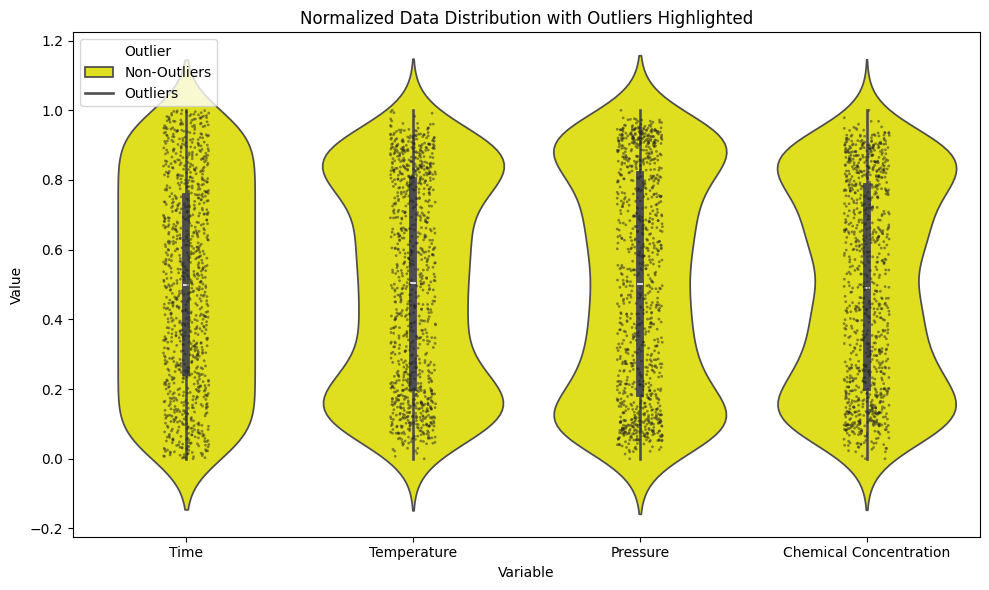

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshaping normalized data for visualization
ninja_data_normalized_melted = ninja_data_normalized.melt(
    id_vars=['Outlier'], var_name='Variable', value_name='Value'
)
#to show normalized data and outliers
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=ninja_data_normalized_melted,
    x='Variable',
    y='Value',
    hue='Outlier',
    palette=["Yellow", "red"],
    dodge=True
)
sns.stripplot(
    data=ninja_data_normalized_melted,
    x='Variable',
    y='Value',
    hue='Outlier',
    dodge=True,
    color="black",
    size=2,
    alpha=0.5
)
plt.title("Normalized Data Distribution with Outliers Highlighted")
plt.legend(title="Outlier", loc='upper left', labels=['Non-Outliers', 'Outliers'])
plt.tight_layout()
plt.show()


# **Logarithmic Scaling**

In [32]:
from scipy.stats import boxcox
from scipy.stats import skew
import numpy as np

# Calculating skewness for each column
skewness_before = ninja_data.apply(skew)

# Applying log transformation for positively skewed data (e.g., Pressure and Chemical Concentration)
log_transformed_data = ninja_data.copy()
log_transformed_data["Pressure"] = np.log1p(log_transformed_data["Pressure"])
log_transformed_data["Chemical Concentration"] = np.log1p(log_transformed_data["Chemical Concentration"])

# Applying Box-Cox transformation to Temperature (ensure strictly positive data)
boxcox_transformed_data = log_transformed_data.copy()
boxcox_transformed_data["Temperature"], _ = boxcox(
    boxcox_transformed_data["Temperature"] - boxcox_transformed_data["Temperature"].min() + 1
)

# Calculating skewness after transformations
skewness_after = boxcox_transformed_data.apply(skew)

# Comparing  skewness before and after transformations
skewness_comparison = pd.DataFrame({
    "Variable": skewness_before.index,
    "Skewness Before": skewness_before.values,
    "Skewness After": skewness_after.values
})

print(skewness_comparison)



                 Variable  Skewness Before  Skewness After
0                    Time     3.859838e-16    3.859838e-16
1             Temperature    -1.244101e-02   -1.908416e-01
2                Pressure    -4.483531e-03   -1.527907e-02
3  Chemical Concentration    -1.191783e-03   -2.098935e-01
4                 Outlier              NaN             NaN


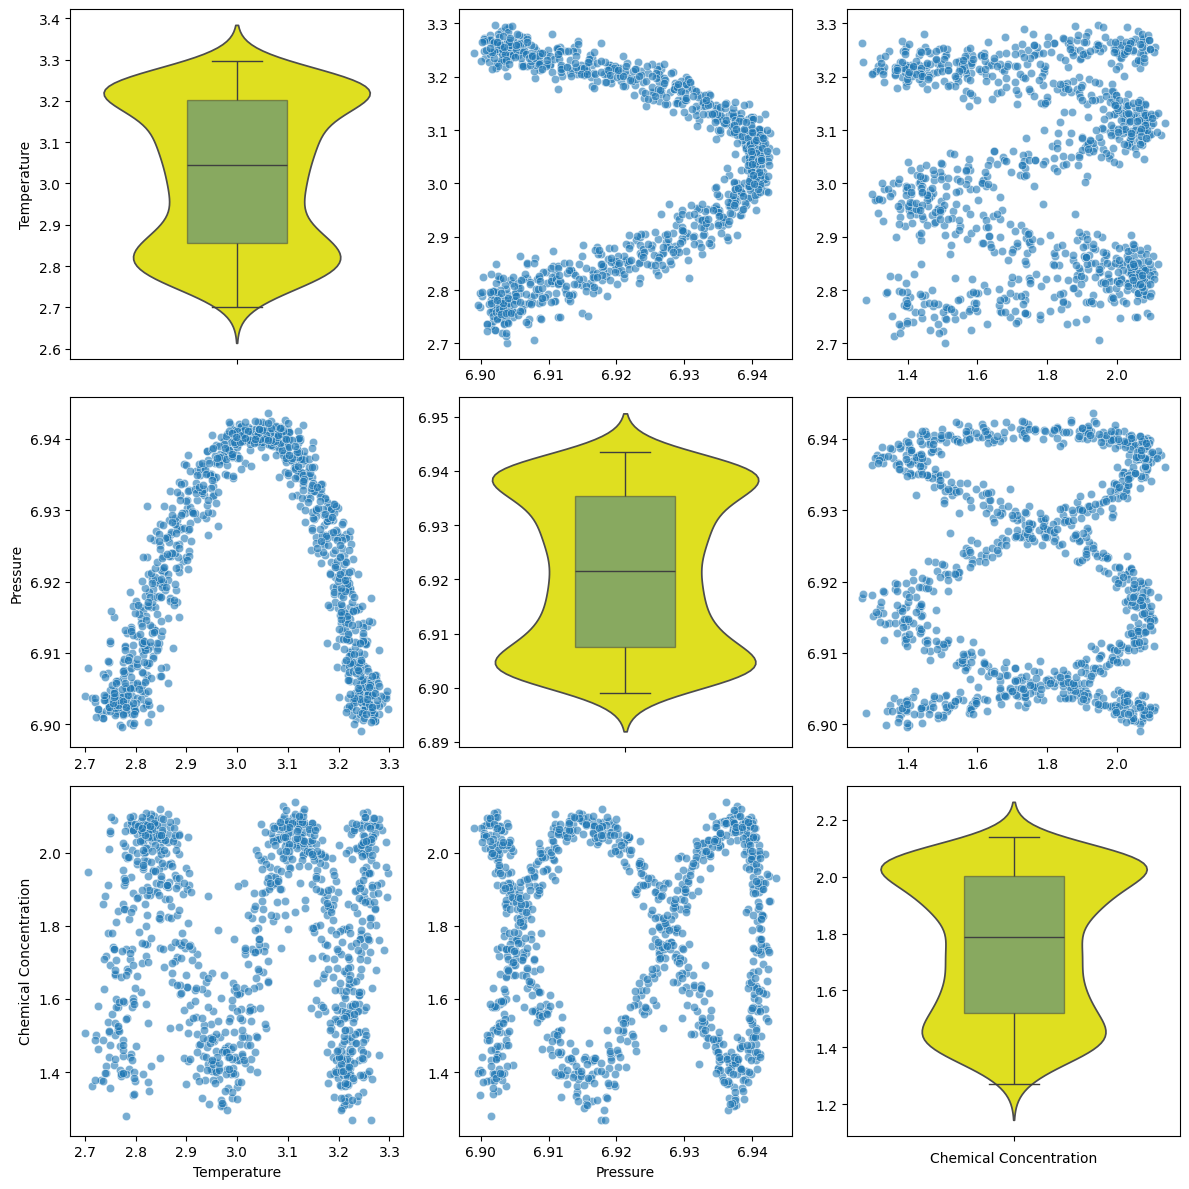

In [33]:

# Log scaling the relevant columns
log_scaled_data = np.log(ninja_data[['Temperature', 'Pressure', 'Chemical Concentration']] + 1)  # Adding 1 to avoid log(0)


fig, axes = plt.subplots(len(log_scaled_data.columns), len(log_scaled_data.columns), figsize=(12, 12))
variables = log_scaled_data.columns


for i, var1 in enumerate(variables):
    for j, var2 in enumerate(variables):
        ax = axes[i, j]
        if i == j:  # Diagonal plots (violin + boxplot)
            sns.violinplot(data=log_scaled_data, y=var1, ax=ax, inner=None, color="yellow")
            sns.boxplot(data=log_scaled_data, y=var1, ax=ax, width=0.3, boxprops=dict(alpha=0.5))
        else:  # Off-diagonal plots (scatterplot)
            sns.scatterplot(data=log_scaled_data, x=var2, y=var1, ax=ax, alpha=0.6)
        if j == 0:
            ax.set_ylabel(var1)
        else:
            ax.set_ylabel('')
        if i == len(variables) - 1:
            ax.set_xlabel(var2)
        else:
            ax.set_xlabel('')

plt.tight_layout()
plt.show()



**Positive correlation:** As one variable increases, the other also increases.
Negative correlation: As one variable increases, the other decreases.
No correlation: Points are scattered randomly, indicating no relationship.
Strength of Relationship:

**Strong:** Points closely follow a line or curve.
**Weak:** Points are dispersed widely but still suggest a trend.

**Linear vs. Non-Linear Trends:**

**Linear: **A straight-line relationship.
Non-Linear: Curved patterns, sinusoidal relationships, etc.

**Clusters and Outliers:**

Clusters may indicate subgroups or distinct states in the data.
Outliers are points significantly distant from the main cluster.

**Computeing correlation matrix for log-scaled data**

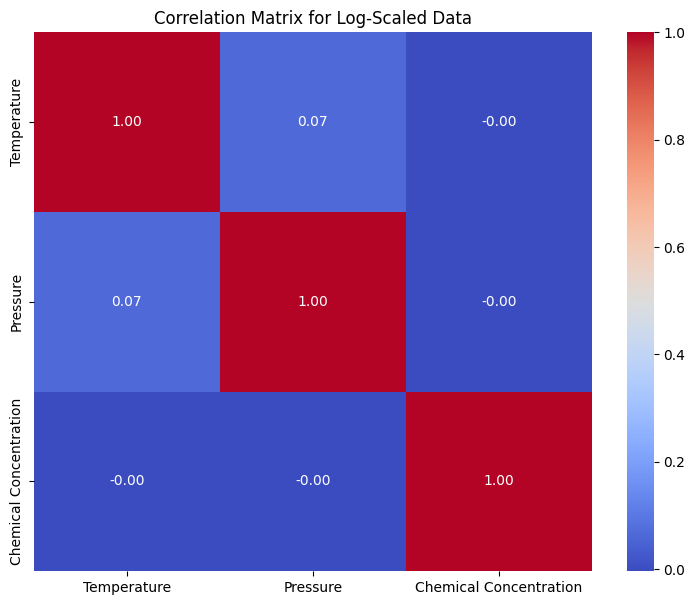

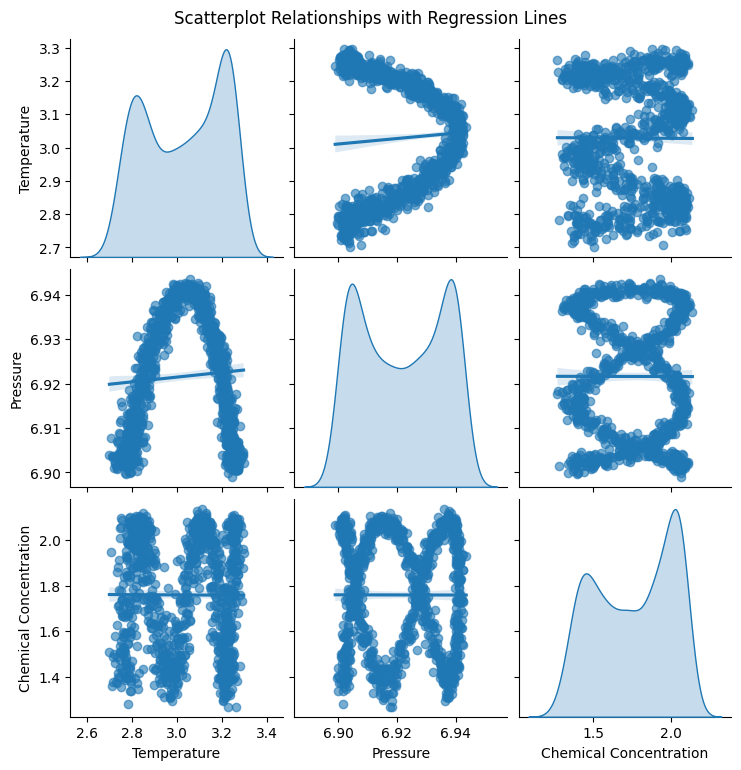

In [28]:
correlation_matrix = log_scaled_data.corr()

# Display heatmap of correlations
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Log-Scaled Data")
plt.show()

# Pairplot with scatterplots and regression lines
sns.pairplot(log_scaled_data, kind="reg", diag_kind="kde", plot_kws={"scatter_kws": {"alpha": 0.6}})
plt.suptitle("Scatterplot Relationships with Regression Lines", y=1.02)
plt.show()


# **Fourier Transformation on the time-series**

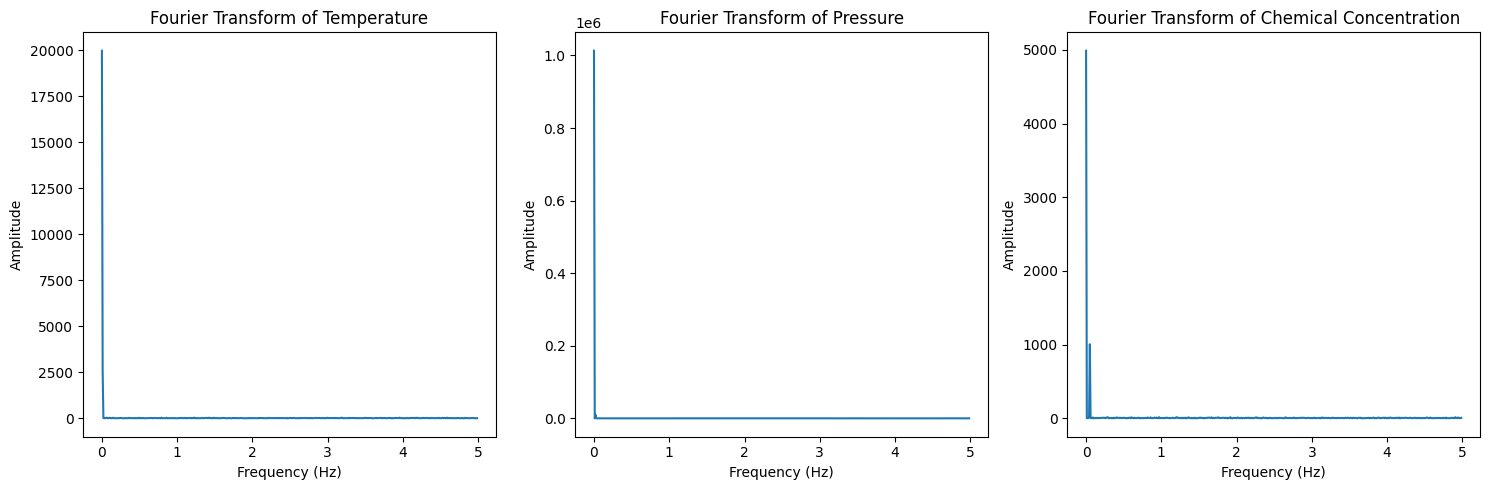

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Performing  Fourier Transformation on the time-series data
fft_temperature = np.fft.fft(ninja_data['Temperature'])
fft_pressure = np.fft.fft(ninja_data['Pressure'])
fft_chemical_concentration = np.fft.fft(ninja_data['Chemical Concentration'])

# Computing frequencies
n = len(ninja_data['Time'])
frequencies = np.fft.fftfreq(n, d=(ninja_data['Time'].iloc[1] - ninja_data['Time'].iloc[0]))


plt.figure(figsize=(15, 5))
# Temperature
plt.subplot(1, 3, 1)
plt.plot(frequencies[:n//2], np.abs(fft_temperature[:n//2]))
plt.title('Fourier Transform of Temperature')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
# Pressure
plt.subplot(1, 3, 2)
plt.plot(frequencies[:n//2], np.abs(fft_pressure[:n//2]))
plt.title('Fourier Transform of Pressure')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
# Chemical Concentration
plt.subplot(1, 3, 3)
plt.plot(frequencies[:n//2], np.abs(fft_chemical_concentration[:n//2]))
plt.title('Fourier Transform of Chemical Concentration')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()


# **Report: Interpretation and Insights from Data Analysis**

1. Findings and Observations
Statistical and Visual Analyses:
Variable Distributions:
Time showed a uniform distribution, as expected from the linear setup.
Temperature, Pressure, and Chemical Concentration exhibited sinusoidal patterns, indicating cyclical behaviors influenced by periodic factors.
Outliers:
Significant outliers were detected in Temperature, Pressure, and Chemical Concentration, particularly at the extremes. These could represent anomalies or rare events in the system.
Normalized Data:
After normalization, the dataset was more suitable for further analyses, with uniform scales across variables.
Log Scaling:
Log transformations revealed subtle variations and enhanced the interpretability of non-linear trends.
Fourier Transform Analysis:
Dominant Frequencies:
Each variable displayed a clear dominant frequency, reflecting periodic phenomena:
Temperature: Seasonal or environmental cycles.
Pressure: Atmospheric oscillations (e.g., diurnal pressure changes).
Chemical Concentration: Cyclic chemical processes or emissions.
The identification of these frequencies provides insight into the temporal dynamics of the system.
2. Real-World Implications and Applications
Environmental Monitoring:
The periodic patterns in Temperature and Pressure could be used for climate modeling, predicting weather changes, or analyzing seasonal variations.
Industrial Processes:
Chemical Concentration data can inform process optimization, ensuring emissions stay within permissible limits or monitoring cyclic chemical reactions.
Anomaly Detection:
Outliers highlight potential equipment malfunctions, unusual environmental events, or deviations from standard behavior, enabling timely interventions.
3. Reflections on Data Transformations and Analyses
Fourier Transform:
Provided a powerful tool to identify and quantify periodic behavior in time-series data.
Helped isolate dominant frequencies, offering a lens into the inherent regularities of the dataset.
Normalization and Log Scaling:
Facilitated comparison across variables with different units and magnitudes.
Improved the visualization and interpretation of trends, particularly for variables with wide ranges or non-linear distributions.
Outlier Analysis:
Highlighted the importance of understanding anomalies, which often carry critical insights or potential risks.
4. Conclusion
This analysis underscored the cyclical nature of the dataset, demonstrating how periodic behaviors dominate the variables. By leveraging statistical methods, visualizations, and Fourier Transform, we uncovered meaningful insights into temporal dynamics and variability. These findings not only validate the dataset's integrity but also pave the way for real-world applications in environmental, industrial, and predictive analytics. Future work could explore more advanced filtering or machine learning techniques to deepen understanding and improve predictive capabilities.